# PatchTST: Transformer-basierte Zeitreihenprognose

Dieses Notebook erklärt die Methode **PatchTST** Schritt für Schritt anhand eines realen Zeitreihendatensatzes. Es richtet sich an Studierende, die Python und grundlegendes maschinelles Lernen kennen, aber Transformer für Zeitreihen noch nicht verwendet haben.

Wir folgen bewusst dem **CRISP-DM-Prozess**:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Methodische Grundlagen von PatchTST
5. Modeling
6. Evaluation
7. Deployment / Interpretation
8. Vergleich mit anderen Methoden
9. Fazit
10. Übungen

Das Ziel ist nicht, ein industrielles Hochleistungsmodell zu bauen, sondern eine verständliche, ausführbare und didaktisch saubere Einführung zu geben.

## Optionale Installation

Falls einzelne Pakete in Ihrer Umgebung fehlen, installiert die nächste Zelle sie automatisch. In bereits vorbereiteten Kursumgebungen ist dieser Schritt meist schnell oder es passiert nichts.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "torch": "torch",
}

missing_packages = [
    package_name
    for import_name, package_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print("Installing missing packages:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are already available.")

All required packages are already available.


## Gemeinsame Imports und Reproduzierbarkeit

Wir setzen Zufallszahlen fest, damit Ergebnisse möglichst reproduzierbar bleiben. Bei neuronalen Netzen können kleine Unterschiede trotzdem auftreten, besonders auf GPUs.

In [2]:
import math
import random
import warnings
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Business Understanding

Zeitreihenprognose bedeutet, zukünftige Werte aus vergangenen Beobachtungen vorherzusagen. In Unternehmen betrifft das zum Beispiel Stromverbrauch, Nachfrage, Auslastung, Verkehr, Preise oder Wettervariablen.

In diesem Notebook betrachten wir ein typisches Prognoseproblem:

> Aus den letzten Stunden einer multivariaten Zeitreihe sollen die nächsten Stunden einer Zielvariable prognostiziert werden.

PatchTST ist dafür relevant, weil viele reale Zeitreihen lang sind. Klassische Transformer werden bei langen Sequenzen schnell teuer. PatchTST reduziert die effektive Sequenzlänge, indem nicht einzelne Zeitpunkte, sondern **Abschnitte der Zeitreihe** als Tokens verwendet werden.

Unser Lernziel:

- verstehen, warum Patches bei Zeitreihen sinnvoll sind,
- eine kleine PatchTST-Variante in PyTorch implementieren,
- ein reales Dataset laden,
- das Modell trainieren und gegen einfache Baselines vergleichen,
- Ergebnisse kritisch interpretieren.

## 2. Data Understanding

Wir verwenden den öffentlich verfügbaren **ETTh1-Datensatz** aus der Electricity Transformer Temperature Collection. Der Datensatz enthält stündliche Messungen eines Stromtransformators, darunter Last- und Temperaturvariablen.

Warum eignet sich dieser Datensatz für PatchTST?

- Er ist eine echte, regelmäßig gemessene Zeitreihe.
- Er enthält mehrere numerische Kanäle.
- Er besitzt genügend Länge für Sliding Windows und Patches.
- Die Zielvariable `OT` wird häufig für Long-Term-Forecasting-Beispiele verwendet.
- Saisonale Muster und Trends sind visuell diskutierbar.

In [3]:
data_url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"

df = pd.read_csv(data_url)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(df.shape)
display(df.head())
display(df.tail())

(17420, 8)


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
17415,2018-06-26 15:00:00,-1.674,3.550,-5.615,2.132,3.472,1.523,10.904
17416,2018-06-26 16:00:00,-5.492,4.287,-9.132,2.274,3.533,1.675,11.044
17417,2018-06-26 17:00:00,2.813,3.818,-0.817,2.097,3.716,1.523,10.271
17418,2018-06-26 18:00:00,9.243,3.818,5.472,2.097,3.655,1.432,9.778
17419,2018-06-26 19:00:00,10.114,3.550,6.183,1.564,3.716,1.462,9.567


### Spalten und Zeitindex

Jede Zeile repräsentiert eine Stunde. Die Spalte `date` ist der Zeitstempel. Alle übrigen Spalten sind numerische Messgrößen. Wir verwenden später `OT` als Zielvariable, behalten aber auch die anderen numerischen Variablen als zusätzliche Kanäle.

In [4]:
print(df.info())
print("\nColumns:", list(df.columns))
print("Time range:", df["date"].min(), "to", df["date"].max())
print("Median time difference:", df["date"].diff().median())

<class 'pandas.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    17420 non-null  datetime64[us]
 1   HUFL    17420 non-null  float64       
 2   HULL    17420 non-null  float64       
 3   MUFL    17420 non-null  float64       
 4   MULL    17420 non-null  float64       
 5   LUFL    17420 non-null  float64       
 6   LULL    17420 non-null  float64       
 7   OT      17420 non-null  float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 1.1 MB
None

Columns: ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
Time range: 2016-07-01 00:00:00 to 2018-06-26 19:00:00
Median time difference: 0 days 01:00:00


### Fehlende Werte

Vor dem Modellieren prüfen wir, ob Werte fehlen. Fehlende Werte sind bei Zeitreihen kritisch, weil Sliding Windows sonst Lücken enthalten können.

In [5]:
missing_values = df.isna().sum()
display(missing_values.to_frame("missing_count"))

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_columns] = df[numeric_columns].interpolate(method="linear").ffill().bfill()

print("Missing values after cleaning:", int(df.isna().sum().sum()))

,missing_count
date,0
HUFL,0
HULL,0
MUFL,0
MULL,0
LUFL,0
LULL,0
OT,0


Missing values after cleaning: 0


### Deskriptive Statistik

Die deskriptive Statistik hilft uns, Größenordnungen, Streuungen und mögliche Ausreißer zu verstehen. Für neuronale Netze ist das besonders wichtig, weil stark unterschiedliche Skalen das Training erschweren können.

In [6]:
display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
HUFL,17420.0,7.375141,7.067744,-22.705999,5.827,8.774,11.788,23.643999
HULL,17420.0,2.242242,2.042342,-4.756000,0.737,2.210,3.684,10.114000
MUFL,17420.0,4.300239,6.826978,-25.087999,3.296,5.970,8.635,17.341000
MULL,17420.0,0.881568,1.809293,-5.934000,-0.284,0.959,2.203,7.747000
LUFL,17420.0,3.066062,1.164506,-1.188000,2.315,2.833,3.625,8.498000
LULL,17420.0,0.856932,0.599552,-1.371000,0.670,0.975,1.218,3.046000
OT,17420.0,13.324672,8.566946,-4.080000,6.964,11.396,18.079,46.007000


### Visuelle Exploration

Zuerst betrachten wir die Zielvariable `OT`. Für eine bessere Übersicht zeigen wir nicht die gesamte Zeitreihe in maximaler Dichte, sondern zusätzlich einen Ausschnitt.

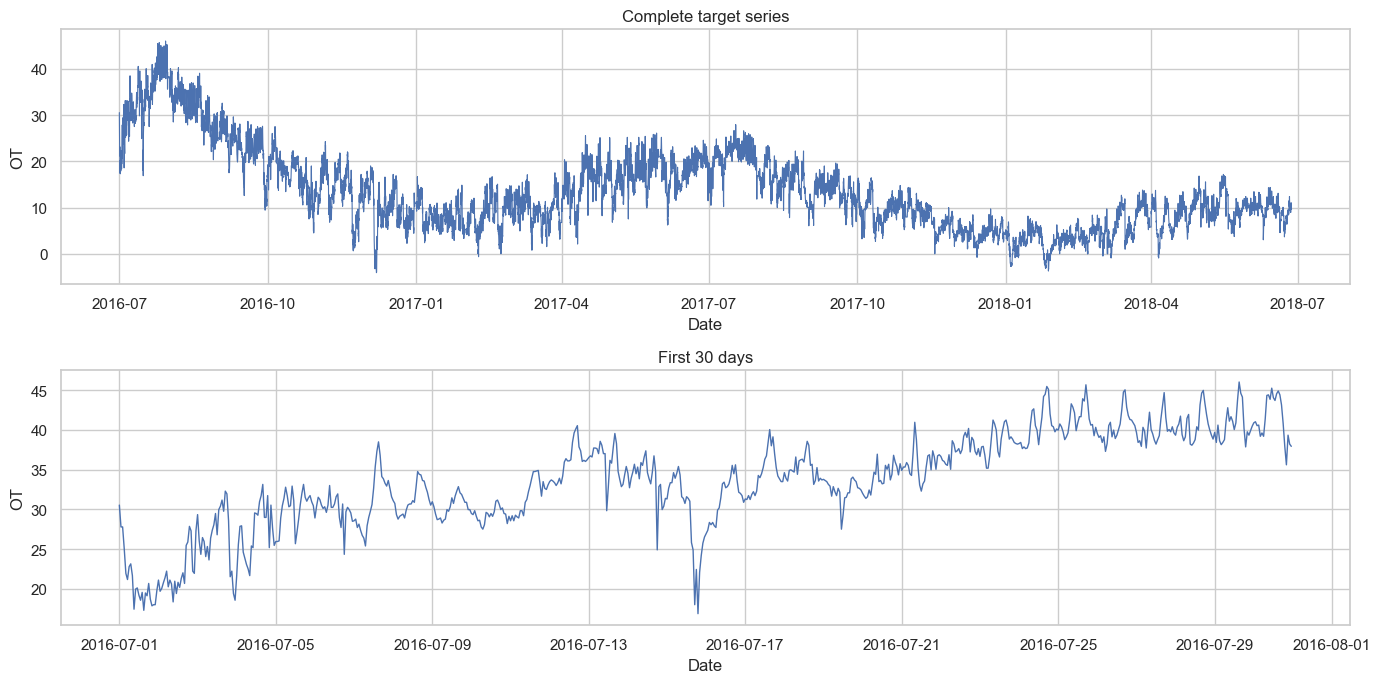

In [7]:
target_column = "OT"

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharey=False)

axes[0].plot(df["date"], df[target_column], linewidth=0.8)
axes[0].set_title("Complete target series")
axes[0].set_xlabel("Date")
axes[0].set_ylabel(target_column)

sample_days = 30
sample_rows = sample_days * 24
axes[1].plot(df["date"].iloc[:sample_rows], df[target_column].iloc[:sample_rows], linewidth=1.0)
axes[1].set_title(f"First {sample_days} days")
axes[1].set_xlabel("Date")
axes[1].set_ylabel(target_column)

plt.tight_layout()
plt.show()

### Saisonale Muster und Korrelationen

Bei stündlichen Daten sind Tagesmuster plausibel: Tageszeit, Last und Temperatur können regelmäßig schwanken. Wir betrachten deshalb ein durchschnittliches 24-Stunden-Profil der Zielvariable und die Korrelationen zwischen numerischen Variablen.

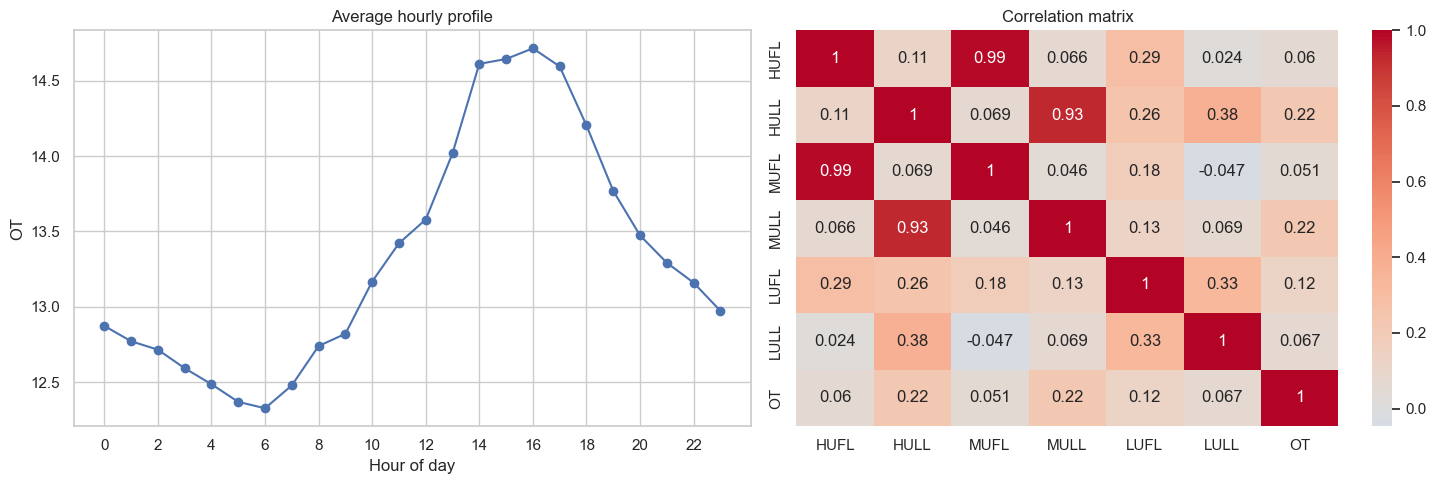

In [8]:
df["hour"] = df["date"].dt.hour
hourly_profile = df.groupby("hour")[target_column].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(hourly_profile.index, hourly_profile.values, marker="o")
axes[0].set_title("Average hourly profile")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel(target_column)
axes[0].set_xticks(range(0, 24, 2))

correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Correlation matrix")

plt.tight_layout()
plt.show()

df = df.drop(columns=["hour"])

**Interpretation:** Wenn Variablen miteinander korrelieren, können zusätzliche Kanäle dem Modell helfen. PatchTST verarbeitet diese Kanäle jedoch in der hier erklärten Grundidee **channel-independent**: Jeder Kanal wird zunächst separat gepatcht und durch denselben Transformer geschickt. Dadurch wird die Modellierung robuster und effizienter.

## 3. Data Preparation

Wir bereiten die Daten so vor, dass keine Information aus der Zukunft ins Training gelangt:

- Split nach Zeitreihenfolge, nicht zufällig.
- Normalisierung nur mit Statistiken des Trainingsbereichs.
- Sliding Windows für Eingabe und Prognoseziel.
- Tensoren im Format `(samples, lookback, channels)` und `(samples, horizon, channels)`.

Wichtige Begriffe:

- **Lookback window:** Wie viele vergangene Zeitschritte das Modell sieht.
- **Forecast horizon:** Wie viele zukünftige Zeitschritte das Modell vorhersagt.

In [9]:
feature_columns = numeric_columns
target_index = feature_columns.index(target_column)

lookback = 96
horizon = 24
patch_length = 16
stride = 8

values = df[feature_columns].astype("float32").values
dates = df["date"].values

train_end = int(len(values) * 0.70)
validation_end = int(len(values) * 0.85)

train_values_raw = values[:train_end]
validation_values_raw = values[train_end:validation_end]
test_values_raw = values[validation_end:]

train_dates = dates[:train_end]
validation_dates = dates[train_end:validation_end]
test_dates = dates[validation_end:]

train_mean = train_values_raw.mean(axis=0, keepdims=True)
train_std = train_values_raw.std(axis=0, keepdims=True)
train_std = np.where(train_std == 0, 1.0, train_std)

train_values = (train_values_raw - train_mean) / train_std
validation_values = (validation_values_raw - train_mean) / train_std
test_values = (test_values_raw - train_mean) / train_std

print("Train rows:", train_values.shape)
print("Validation rows:", validation_values.shape)
print("Test rows:", test_values.shape)
print("Number of channels:", len(feature_columns))

Train rows: (12194, 7)
Validation rows: (2613, 7)
Test rows: (2613, 7)
Number of channels: 7


### Sliding Windows

Ein Sliding Window erzeugt viele Trainingsbeispiele aus einer langen Zeitreihe. Für jedes Beispiel nimmt man einen Vergangenheitsblock der Länge `lookback` und den direkt folgenden Zukunftsblock der Länge `horizon`.

Mathematisch:

\[
X_i = [x_i, x_{i+1}, \dots, x_{i+L-1}]
\]

\[
y_i = [x_{i+L}, x_{i+L+1}, \dots, x_{i+L+H-1}]
\]

Dabei ist \(L\) die Lookback-Länge und \(H\) der Prognosehorizont.

In [10]:
def create_sliding_windows(data, lookback_length, horizon_length):
    # Create input and target windows from a multivariate time series.
    inputs = []
    targets = []
    max_start = len(data) - lookback_length - horizon_length + 1

    for start in range(max_start):
        end = start + lookback_length
        target_end = end + horizon_length
        inputs.append(data[start:end])
        targets.append(data[end:target_end])

    return np.stack(inputs).astype("float32"), np.stack(targets).astype("float32")


X_train, y_train = create_sliding_windows(train_values, lookback, horizon)
X_validation, y_validation = create_sliding_windows(validation_values, lookback, horizon)
X_test, y_test = create_sliding_windows(test_values, lookback, horizon)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (12075, 96, 7)
y_train: (12075, 24, 7)
X_validation: (2494, 96, 7)
y_validation: (2494, 24, 7)
X_test: (2494, 96, 7)
y_test: (2494, 24, 7)


### Konzeptuelles Mini-Beispiel: Patches

Statt einzelne Zeitpunkte als Tokens zu verwenden, teilt PatchTST die Zeitreihe in kurze Abschnitte. Ein Patch ist also ein kleiner Vektor aus aufeinanderfolgenden Zeitpunkten.

Bei `patch_length = 4` und `stride = 2` entstehen überlappende Patches:

- Patch 1: Position 0 bis 3
- Patch 2: Position 2 bis 5
- Patch 3: Position 4 bis 7

Überlappung erhöht die Anzahl der Patches und kann lokale Übergänge besser erfassen. Nicht überlappende Patches sind günstiger, aber gröber.

Toy sequence: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Patch starts: [0, 2, 4, 6, 8, 10, 12]
Patches:
 [[ 1  2  3  4]
 [ 3  4  5  6]
 [ 5  6  7  8]
 [ 7  8  9 10]
 [ 9 10 11 12]
 [11 12 13 14]
 [13 14 15 16]]


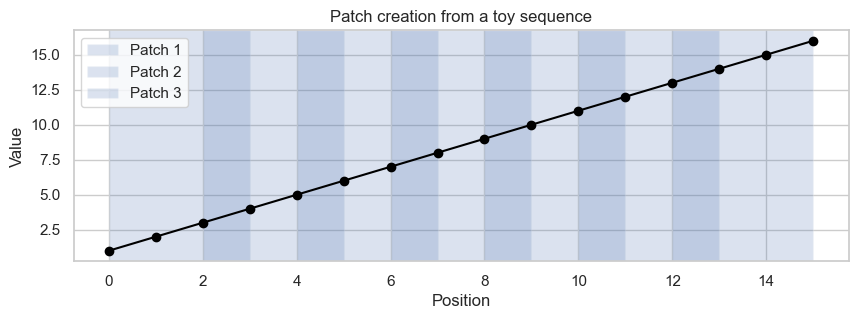

In [11]:
toy_sequence = np.arange(1, 17)
toy_patch_length = 4
toy_stride = 2

def create_1d_patches(sequence, patch_size, patch_stride):
    # Create one-dimensional patches for visualization.
    patches = []
    starts = []
    for start in range(0, len(sequence) - patch_size + 1, patch_stride):
        patches.append(sequence[start:start + patch_size])
        starts.append(start)
    return np.array(patches), starts


toy_patches, toy_starts = create_1d_patches(toy_sequence, toy_patch_length, toy_stride)
print("Toy sequence:", toy_sequence)
print("Patch starts:", toy_starts)
print("Patches:\n", toy_patches)

plt.figure(figsize=(10, 3))
plt.plot(toy_sequence, marker="o", color="black")
for patch_id, start in enumerate(toy_starts):
    end = start + toy_patch_length - 1
    plt.axvspan(start, end, alpha=0.20, label=f"Patch {patch_id + 1}" if patch_id < 3 else None)
plt.title("Patch creation from a toy sequence")
plt.xlabel("Position")
plt.ylabel("Value")
plt.legend(loc="upper left")
plt.show()

### Patch-Anzahl und Tensorformen

Die Anzahl der Patches ergibt sich aus:

\[
N_\text{patches} = \left\lfloor \frac{L - P}{S} \right\rfloor + 1
\]

Dabei ist \(L\) die Lookback-Länge, \(P\) die Patch-Länge und \(S\) der Stride.

In [12]:
def count_patches(sequence_length, patch_size, patch_stride):
    # Compute the number of patches for a sequence.
    return ((sequence_length - patch_size) // patch_stride) + 1


num_patches = count_patches(lookback, patch_length, stride)
print("Lookback:", lookback)
print("Patch length:", patch_length)
print("Stride:", stride)
print("Number of patches:", num_patches)

Lookback: 96
Patch length: 16
Stride: 8
Number of patches: 11


## 4. Methodische Grundlagen von PatchTST

### Transformer-Kurzüberblick

Ein Transformer verarbeitet eine Sequenz von Tokens. In Sprache sind Tokens oft Wörter oder Wortteile. In Zeitreihen könnte man zunächst jeden Zeitpunkt als Token betrachten.

Das Problem: Self-Attention vergleicht jedes Token mit jedem anderen Token. Bei einer Sequenzlänge \(T\) entstehen ungefähr \(T^2\) Paarvergleiche. Lange Zeitreihen werden dadurch teuer.

### Warum einzelne Zeitpunkte schwache Tokens sind

Ein einzelner Messwert enthält oft wenig Kontext. Erst mehrere benachbarte Werte zeigen lokale Formen wie Anstieg, Abfall, Peak oder saisonales Muster. Patches bündeln diese lokale Information.

### Idee von PatchTST

PatchTST macht aus einer Zeitreihe mehrere Patches. Jeder Patch wird eingebettet, erhält eine Positionsinformation und wird dann durch einen Transformer Encoder verarbeitet.

Vereinfachter Ablauf:

1. Eingabezeitreihe mit Länge `lookback`.
2. Zerlegung in Patches.
3. Lineare Patch-Embedding-Schicht.
4. Addieren einer Positionskodierung.
5. Transformer Encoder mit Self-Attention.
6. Prediction Head für den Prognosehorizont.

### Channel Independence

Bei multivariaten Zeitreihen kann PatchTST jeden Kanal zunächst wie eine eigene univariate Zeitreihe behandeln. Die gleiche Modelllogik wird auf alle Kanäle angewandt. Das reduziert Komplexität und kann Generalisierung verbessern.

### Loss Function und Training

Wir verwenden den Mean Squared Error:

\[
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
\]

Der Optimierer passt die Gewichte so an, dass die Prognosen näher an den echten Zukunftswerten liegen.

## 5. Modeling

Wir implementieren eine kleine, lesbare PatchTST-Variante in PyTorch. Sie ist bewusst kompakt:

- Patching mit `unfold`
- lineares Patch Embedding
- lernbare Positionskodierung
- Transformer Encoder
- lineare Vorhersage für den Forecast Horizon

Die Ausgabe hat die Form `(batch, horizon, channels)`.

In [13]:
@dataclass
class PatchTSTConfig:
    lookback: int
    horizon: int
    num_channels: int
    patch_length: int
    stride: int
    d_model: int = 64
    n_heads: int = 4
    num_layers: int = 2
    dropout: float = 0.10

    @property
    def num_patches(self):
        return ((self.lookback - self.patch_length) // self.stride) + 1


class EducationalPatchTST(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.patch_embedding = nn.Linear(config.patch_length, config.d_model)
        self.position_embedding = nn.Parameter(torch.zeros(1, config.num_patches, config.d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.d_model,
            nhead=config.n_heads,
            dim_feedforward=config.d_model * 4,
            dropout=config.dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=config.num_layers)
        self.dropout = nn.Dropout(config.dropout)
        self.prediction_head = nn.Linear(config.num_patches * config.d_model, config.horizon)

    def forward(self, x, print_shapes=False):
        # Run a channel-independent PatchTST forward pass.
        batch_size, lookback_length, num_channels = x.shape

        if print_shapes:
            print("Input:", x.shape)

        x = x.permute(0, 2, 1)
        x = x.reshape(batch_size * num_channels, lookback_length)

        patches = x.unfold(dimension=-1, size=self.config.patch_length, step=self.config.stride)

        if print_shapes:
            print("Patches:", patches.shape)

        embedded = self.patch_embedding(patches)
        embedded = embedded + self.position_embedding
        embedded = self.dropout(embedded)

        if print_shapes:
            print("Embedded patches:", embedded.shape)

        encoded = self.encoder(embedded)

        if print_shapes:
            print("Encoded patches:", encoded.shape)

        flattened = encoded.reshape(batch_size * num_channels, -1)
        forecast = self.prediction_head(flattened)
        forecast = forecast.reshape(batch_size, num_channels, self.config.horizon)
        forecast = forecast.permute(0, 2, 1)

        if print_shapes:
            print("Forecast:", forecast.shape)

        return forecast


config = PatchTSTConfig(
    lookback=lookback,
    horizon=horizon,
    num_channels=len(feature_columns),
    patch_length=patch_length,
    stride=stride,
)

model = EducationalPatchTST(config).to(device)
print(config)
print("Trainable parameters:", sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad))

PatchTSTConfig(lookback=96, horizon=24, num_channels=7, patch_length=16, stride=8, d_model=64, n_heads=4, num_layers=2, dropout=0.1)
Trainable parameters: 118680


### Sanity Check der Tensorformen

Bevor wir trainieren, schicken wir einen kleinen Batch durch das Modell. So sehen wir die wichtigsten Formen der PatchTST-Pipeline.

In [14]:
sample_batch = torch.tensor(X_train[:4], dtype=torch.float32).to(device)
with torch.no_grad():
    sample_output = model(sample_batch, print_shapes=True)

assert sample_output.shape == (4, horizon, len(feature_columns))

Input: torch.Size([4, 96, 7])
Patches: torch.Size([28, 11, 16])
Embedded patches: torch.Size([28, 11, 64])
Encoded patches: torch.Size([28, 11, 64])
Forecast: torch.Size([4, 24, 7])


### DataLoader

Für eine schnelle Demonstration begrenzen wir die Anzahl der Trainingsfenster. Der Testbereich bleibt unverändert. In einer ernsthaften Modellierung würde man mehr Epochen, Hyperparameter-Suche und eventuell den vollständigen Trainingsbereich verwenden.

In [15]:
max_train_windows = 2500
max_validation_windows = 800
batch_size = 64

X_train_small = X_train[:max_train_windows]
y_train_small = y_train[:max_train_windows]
X_validation_small = X_validation[:max_validation_windows]
y_validation_small = y_validation[:max_validation_windows]

train_dataset = TensorDataset(
    torch.tensor(X_train_small, dtype=torch.float32),
    torch.tensor(y_train_small, dtype=torch.float32),
)
validation_dataset = TensorDataset(
    torch.tensor(X_validation_small, dtype=torch.float32),
    torch.tensor(y_validation_small, dtype=torch.float32),
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32),
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Training batches: 40
Validation batches: 13
Test batches: 39


### Training Loop

Wir trainieren mit AdamW und MSELoss. Die Loss wird auf alle Kanäle berechnet. Für die spätere Interpretation konzentrieren wir uns auf die Zielvariable `OT`.

In [16]:
def run_one_epoch(model, data_loader, criterion, optimizer=None):
    # Train or evaluate one epoch.
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_observations = 0

    for batch_inputs, batch_targets in data_loader:
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        if is_training:
            optimizer.zero_grad()

        predictions = model(batch_inputs)
        loss = criterion(predictions, batch_targets)

        if is_training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        batch_size_current = batch_inputs.size(0)
        total_loss += loss.item() * batch_size_current
        total_observations += batch_size_current

    return total_loss / total_observations


criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 8
training_losses = []
validation_losses = []

for epoch in range(1, num_epochs + 1):
    train_loss = run_one_epoch(model, train_loader, criterion, optimizer)
    validation_loss = run_one_epoch(model, validation_loader, criterion, optimizer=None)

    training_losses.append(train_loss)
    validation_losses.append(validation_loss)

    print(f"Epoch {epoch:02d} | train loss: {train_loss:.4f} | validation loss: {validation_loss:.4f}")

Epoch 01 | train loss: 0.3760 | validation loss: 0.3396
Epoch 02 | train loss: 0.2497 | validation loss: 0.3761
Epoch 03 | train loss: 0.2251 | validation loss: 0.3494
Epoch 04 | train loss: 0.2151 | validation loss: 0.3246
Epoch 05 | train loss: 0.2050 | validation loss: 0.3604
Epoch 06 | train loss: 0.1991 | validation loss: 0.4019
Epoch 07 | train loss: 0.1923 | validation loss: 0.4506
Epoch 08 | train loss: 0.1939 | validation loss: 0.4887


### Trainingsverlauf

Der Trainings- und Validierungsverlust zeigt, ob das Modell lernt und ob es stark überangepasst wirkt. Bei wenigen Epochen erwarten wir keine perfekte Prognose, aber eine fallende Tendenz ist ein gutes Zeichen.

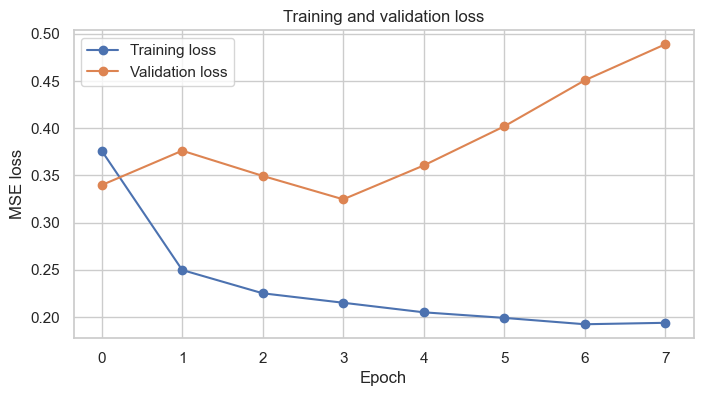

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(training_losses, marker="o", label="Training loss")
plt.plot(validation_losses, marker="o", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

## 6. Evaluation

Wir evaluieren auf dem Testbereich, der zeitlich nach Training und Validierung liegt. Zusätzlich vergleichen wir PatchTST mit zwei einfachen Baselines:

- **Naive Forecast:** Der letzte beobachtete Wert wird für alle Zukunftsschritte wiederholt.
- **Moving Average:** Der Durchschnitt der letzten 24 Stunden wird für alle Zukunftsschritte wiederholt.

Baselines sind wichtig, weil ein komplexes Modell nur dann überzeugend ist, wenn es einfache Regeln schlägt.

In [18]:
def collect_predictions(model, data_loader):
    # Collect model predictions and targets.
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for batch_inputs, batch_targets in data_loader:
            batch_inputs = batch_inputs.to(device)
            batch_predictions = model(batch_inputs).cpu().numpy()
            predictions.append(batch_predictions)
            targets.append(batch_targets.numpy())

    return np.concatenate(predictions), np.concatenate(targets)


patchtst_predictions_scaled, test_targets_scaled = collect_predictions(model, test_loader)

naive_predictions_scaled = np.repeat(X_test[:, -1:, :], repeats=horizon, axis=1)
moving_average_predictions_scaled = np.repeat(
    X_test[:, -24:, :].mean(axis=1, keepdims=True),
    repeats=horizon,
    axis=1,
)

def inverse_scale(scaled_values):
    # Transform scaled values back to the original units.
    return scaled_values * train_std.reshape(1, 1, -1) + train_mean.reshape(1, 1, -1)


patchtst_predictions = inverse_scale(patchtst_predictions_scaled)
naive_predictions = inverse_scale(naive_predictions_scaled)
moving_average_predictions = inverse_scale(moving_average_predictions_scaled)
test_targets = inverse_scale(test_targets_scaled)

### Metriken

Wir verwenden:

- **MAE:** durchschnittlicher absoluter Fehler.
- **MSE:** durchschnittlicher quadratischer Fehler.
- **RMSE:** Wurzel aus MSE, wieder in Originaleinheit.
- **MAPE:** prozentualer Fehler. MAPE ist problematisch, wenn echte Werte nahe null liegen; hier ist das weniger kritisch.

In [19]:
def compute_metrics(y_true, y_pred):
    # Compute common regression metrics.
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    mse = mean_squared_error(y_true_flat, y_pred_flat)
    rmse = math.sqrt(mse)
    denominator = np.maximum(np.abs(y_true_flat), 1e-8)
    mape = np.mean(np.abs((y_true_flat - y_pred_flat) / denominator)) * 100
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE": mape}


target_slice = np.s_[:, :, target_index]

metrics_table = pd.DataFrame(
    {
        "PatchTST": compute_metrics(test_targets[target_slice], patchtst_predictions[target_slice]),
        "Naive": compute_metrics(test_targets[target_slice], naive_predictions[target_slice]),
        "Moving Average": compute_metrics(test_targets[target_slice], moving_average_predictions[target_slice]),
    }
).T

display(metrics_table.round(4))

,MAE,MSE,RMSE,MAPE
PatchTST,3.7876,20.8860,4.5701,261039008.0
Naive,1.4597,3.9941,1.9985,56777944.0
Moving Average,1.6079,4.6579,2.1582,96237584.0


**Interpretation:** Entscheidend ist nicht nur, ob PatchTST einen niedrigen Fehler erreicht, sondern ob es die einfachen Baselines übertrifft. Wenn eine Baseline ähnlich gut ist, kann das bedeuten, dass der Prognosehorizont kurz ist, das Training zu knapp war oder die Zeitreihe stark persistent ist.

### Predicted vs. Actual

Wir visualisieren ein einzelnes Testfenster. Die Eingabe zeigt die Vergangenheit, danach vergleichen wir echte Zukunft und Prognosen.

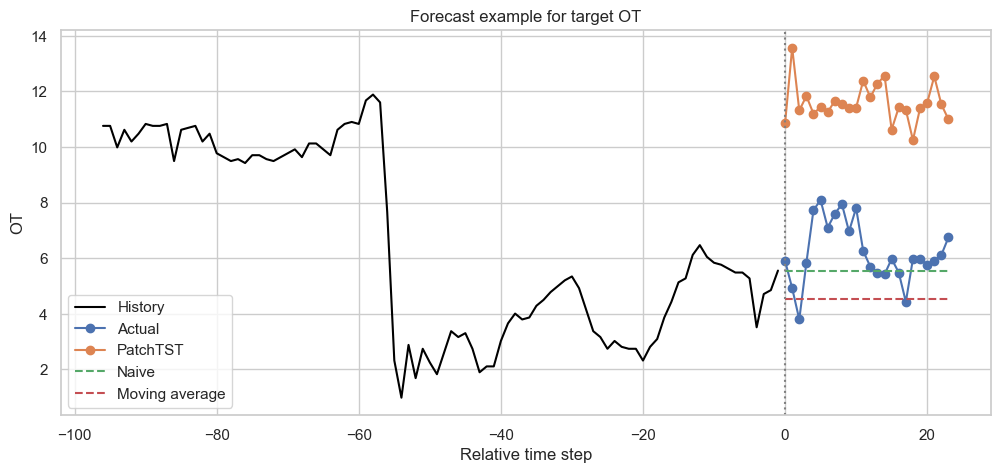

In [20]:
example_index = 100

history_scaled = X_test[example_index, :, target_index]
history = history_scaled * train_std[0, target_index] + train_mean[0, target_index]
actual_future = test_targets[example_index, :, target_index]
patchtst_future = patchtst_predictions[example_index, :, target_index]
naive_future = naive_predictions[example_index, :, target_index]
moving_average_future = moving_average_predictions[example_index, :, target_index]

history_axis = np.arange(-lookback, 0)
future_axis = np.arange(0, horizon)

plt.figure(figsize=(12, 5))
plt.plot(history_axis, history, label="History", color="black")
plt.plot(future_axis, actual_future, label="Actual", marker="o")
plt.plot(future_axis, patchtst_future, label="PatchTST", marker="o")
plt.plot(future_axis, naive_future, label="Naive", linestyle="--")
plt.plot(future_axis, moving_average_future, label="Moving average", linestyle="--")
plt.axvline(x=0, color="gray", linestyle=":")
plt.title("Forecast example for target OT")
plt.xlabel("Relative time step")
plt.ylabel(target_column)
plt.legend()
plt.show()

### Fehleranalyse nach Prognoseschritt

Viele Modelle sind für den ersten Zukunftsschritt besser als für spätere Schritte. Deshalb betrachten wir den MAE pro Horizontposition.

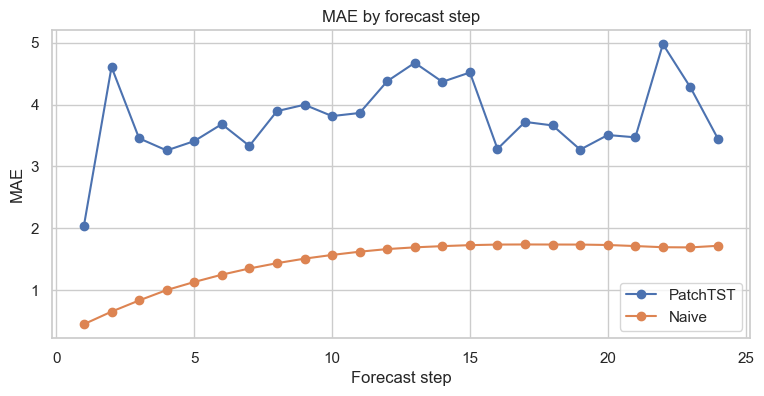

In [21]:
step_mae_patchtst = np.mean(
    np.abs(test_targets[target_slice] - patchtst_predictions[target_slice]),
    axis=0,
)
step_mae_naive = np.mean(
    np.abs(test_targets[target_slice] - naive_predictions[target_slice]),
    axis=0,
)

plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, horizon + 1), step_mae_patchtst, marker="o", label="PatchTST")
plt.plot(np.arange(1, horizon + 1), step_mae_naive, marker="o", label="Naive")
plt.title("MAE by forecast step")
plt.xlabel("Forecast step")
plt.ylabel("MAE")
plt.legend()
plt.show()

## 7. Deployment / Interpretation und Diskussion

In einem realen Einsatz würde man das Modell regelmäßig mit neuen Daten versorgen, die letzten `lookback` Zeitschritte normalisieren und anschließend die nächsten `horizon` Schritte vorhersagen. Wichtig ist, dieselben Trainingsstatistiken für die Skalierung zu verwenden.

Was kann das Modell gelernt haben?

- lokale Muster innerhalb von Patches,
- wiederkehrende Tages- oder Lastprofile,
- glatte Übergänge zwischen Vergangenheit und Zukunft,
- robuste Repräsentationen über mehrere Kanäle.

### Einfluss von Patch-Länge und Stride

Eine größere Patch-Länge fasst mehr lokale Information zusammen, reduziert aber die Anzahl der Tokens. Ein kleinerer Stride erzeugt mehr überlappende Patches, kostet aber mehr Rechenzeit.

### Stärken von PatchTST

- effizienter als Standard-Transformer auf langen Sequenzen,
- gut für längere Lookback-Fenster,
- verständliche Idee durch Patches,
- geeignet für multivariate Zeitreihen,
- häufig stark in Long-Term-Forecasting-Benchmarks.

### Grenzen von PatchTST

- braucht ausreichend Daten,
- Hyperparameter wie Patch-Länge, Stride und Horizon sind wichtig,
- keine automatische Erklärung kausaler Zusammenhänge,
- bei sehr kleinen Datensätzen können klassische Modelle besser sein,
- Foundation-Modelle können bei Zero-Shot-Szenarien praktischer sein.

## 8. Vergleich mit anderen Methoden

### PatchTST vs. ARIMA

ARIMA modelliert lineare Abhängigkeiten, Trends und Autokorrelationen explizit. Es ist oft stark bei kleinen, univariaten und gut verstandenen Zeitreihen. PatchTST ist flexibler, datenhungriger und kann nichtlineare Muster in längeren Sequenzen lernen.

### PatchTST vs. LSTM

LSTMs lesen Sequenzen rekurrent, also Schritt für Schritt. Das kann bei langen Sequenzen schwer zu trainieren sein. PatchTST verarbeitet Patches parallel und nutzt Self-Attention, um Beziehungen zwischen Zeitabschnitten zu modellieren.

### PatchTST vs. Standard Transformer

Ein Standard Transformer würde jeden Zeitpunkt als Token betrachten. Bei langen Lookback-Fenstern wird Self-Attention teuer. PatchTST verkürzt die Token-Sequenz, indem mehrere Zeitpunkte zu einem Patch zusammengefasst werden.

### PatchTST vs. Chronos und Foundation-Modelle

Chronos und ähnliche Foundation-Modelle werden auf sehr vielen Zeitreihen vortrainiert und können teils ohne projektspezifisches Training eingesetzt werden. PatchTST ist dagegen ein Architekturansatz, den man typischerweise auf den eigenen Daten trainiert oder feinjustiert. Foundation-Modelle sind komfortabel für schnelle Zero-Shot-Prognosen, PatchTST ist gut, wenn man ein kontrollierbares, projektspezifisches Modell trainieren möchte.

## 9. Fazit

PatchTST überträgt Transformer-Ideen auf Zeitreihen, indem es nicht einzelne Zeitpunkte, sondern Patches als Tokens verwendet. Dadurch wird Self-Attention günstiger und die Tokens enthalten mehr lokale Information.

Zentrale Erkenntnisse:

- Zeitreihen müssen zeitlich korrekt gesplittet werden.
- Normalisierung darf nur Trainingsstatistiken verwenden.
- Patches verbinden lokale Muster mit globaler Attention.
- Baselines sind unverzichtbar für eine faire Bewertung.
- Gute Ergebnisse hängen stark von Lookback, Horizon, Patch-Länge, Stride und Trainingsdauer ab.

Mögliche Erweiterungen:

- längeres Training,
- Hyperparameter-Vergleich,
- vollständiger Trainingsdatensatz,
- andere Zielvariable,
- probabilistische Prognosen,
- Vergleich mit ARIMA, LSTM oder Foundation-Modellen.

## 10. Übungen

1. Ändern Sie `patch_length` von 16 auf 8 oder 24. Wie verändern sich Anzahl der Patches, Trainingszeit und Testfehler?
2. Ändern Sie den `horizon` von 24 auf 48. Wird die Prognose deutlich schwieriger?
3. Verwenden Sie eine andere Zielvariable, zum Beispiel `HUFL` oder `MULL`. Welche Variable ist leichter zu prognostizieren?
4. Trainieren Sie mit mehr Trainingsfenstern oder mehr Epochen. Verbessert sich PatchTST gegenüber der Naive-Baseline?
5. Implementieren Sie eine zusätzliche Baseline, zum Beispiel den Wert derselben Stunde am Vortag. Vergleichen Sie die Metriken mit PatchTST.